# Inspect encoded embeddings

This notebook loads an encoded embedding file (NumPy `.npy`) and runs quick diagnostics:
- shape and basic stats
- per-dimension standard deviation summary
- distribution of pairwise distances
- 2D t-SNE visualization (colored by label if available)

Set `ENCODED_NPY` below to the path of your `encoded_mean.npy`. If you saved CSV with sample ids, `ENCODED_CSV` will be auto-loaded for labels.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
try:
    import umap
    _have_umap = True
except Exception:
    _have_umap = False

print('umap available:', _have_umap)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.
umap available: True


In [3]:
# Paths: update ENCODED_NPY if needed
ENCODED_NPY = '/data/horse/ws/mala059b-rna2wsi/vae_output/demo/encoded_mean.npy'
ENCODED_CSV = ENCODED_NPY.replace('.npy', '.csv')
POSSIBLE_LABEL_CSV = '/data/horse/ws/mala059b-rna2wsi/data/brca_gene_expression_with_subtypes.csv'

if not os.path.exists(ENCODED_NPY):
    raise FileNotFoundError(f'Encoded file not found: {ENCODED_NPY}. Update path in the cell.')
z = np.load(ENCODED_NPY)
print('Loaded', ENCODED_NPY, 'shape =', z.shape)

encoded_df = None
if os.path.exists(ENCODED_CSV):
    try:
        encoded_df = pd.read_csv(ENCODED_CSV, index_col=0)
        print('Loaded encoded CSV:', ENCODED_CSV, 'shape =', encoded_df.shape)
    except Exception as e:
        print('Could not load encoded CSV:', e)

label_df = None
if os.path.exists(POSSIBLE_LABEL_CSV):
    try:
        label_df = pd.read_csv(POSSIBLE_LABEL_CSV, index_col=0)
        print('Loaded possible label CSV:', POSSIBLE_LABEL_CSV, 'shape =', label_df.shape)
    except Exception as e:
        print('Could not load label CSV:', e)

Loaded /data/horse/ws/mala059b-rna2wsi/vae_output/demo/encoded_mean.npy shape = (996, 128)
Loaded possible label CSV: /data/horse/ws/mala059b-rna2wsi/data/brca_gene_expression_with_subtypes.csv shape = (996, 19963)


std summary:
 count    128.000000
mean       0.657451
std        0.256363
min        0.289542
25%        0.465862
50%        0.609810
75%        0.801205
max        1.768453
dtype: float64

mean summary:
 count    128.000000
mean       0.008960
std        0.172881
min       -0.459725
25%       -0.095209
50%        0.020270
75%        0.138802
max        0.437183
dtype: float64

number of latent dims = 128
dimensions with zero std = 0


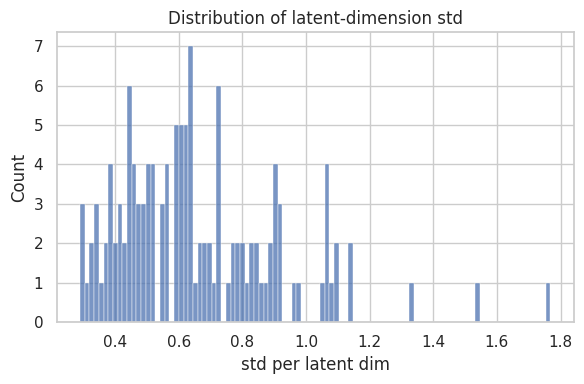

In [4]:
# Per-dimension std/mean summary
stds = np.std(z, axis=0)
means = np.mean(z, axis=0)
std_summary = pd.Series(stds).describe()
mean_summary = pd.Series(means).describe()
print('std summary:\n', std_summary)
print('\nmean summary:\n', mean_summary)

n_dims = z.shape[1]
n_zero_std = int((stds == 0).sum())
print('\nnumber of latent dims =', n_dims)
print('dimensions with zero std =', n_zero_std)

plt.figure(figsize=(6,4))
sns.histplot(stds, bins=100, kde=False)
plt.xlabel('std per latent dim')
plt.title('Distribution of latent-dimension std')
plt.tight_layout()
plt.show()

In [5]:
# Pairwise distances summary (subsample if large)
n_samples = z.shape[0]
if n_samples > 5000:
    print(f'Large sample count ({n_samples}): computing distances on random subsample of 2000')
    idx = np.random.choice(n_samples, size=2000, replace=False)
    z_small = z[idx]
else:
    z_small = z

d = pairwise_distances(z_small)
pcts = np.percentile(d.flatten(), [0,1,5,25,50,75,95,99,100])
print('pairwise distance percentiles:', pcts)

pairwise distance percentiles: [  0.           2.26970983   3.10202432   4.9507519    6.90332842
   9.19578099  16.72117233  38.68338394 131.59796143]


In [6]:
# Prepare labels if available
labels = None
label_name = None
if encoded_df is not None:
    for candidate in ['Majority_Subtype_mRNA', 'label', 'subtype', 'class']:
        if candidate in encoded_df.columns:
            labels = encoded_df[candidate].values
            label_name = candidate
            print('Using labels from encoded CSV column:', candidate)
            break

if labels is None and label_df is not None:
    for candidate in ['Majority_Subtype_mRNA', 'PAM50', 'subtype', 'label']:
        if candidate in label_df.columns:
            try:
                if encoded_df is not None:
                    idx = encoded_df.index
                    labels = label_df.loc[idx, candidate].values
                else:
                    labels = label_df[candidate].iloc[:z.shape[0]].values
                label_name = candidate
                print('Using labels from original CSV column:', candidate)
                break
            except Exception:
                pass

print('labels found:', labels is not None, 'label_name=', label_name)

Using labels from original CSV column: Majority_Subtype_mRNA
labels found: True label_name= Majority_Subtype_mRNA


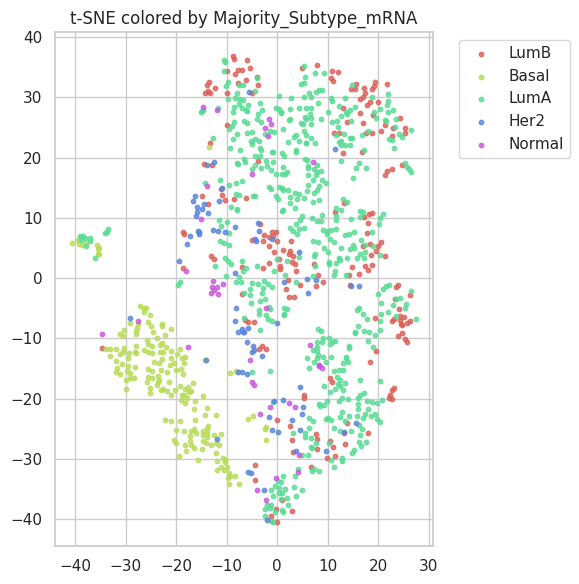

/data/horse/ws/mala059b-rna2wsi/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


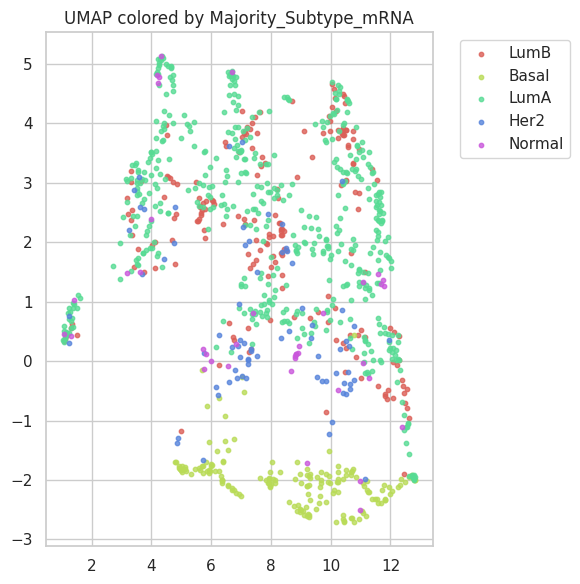

In [7]:
# 2D t-SNE visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=0, init='random')
z2 = tsne.fit_transform(z)
plt.figure(figsize=(6,6))
if labels is None:
    plt.scatter(z2[:,0], z2[:,1], s=10, alpha=0.7)
    plt.title('t-SNE (no labels)')
else:
    try:
        lab_series = pd.Series(labels).astype(str)
        uniq = lab_series.unique()
        palette = sns.color_palette('hls', len(uniq))
        for i, u in enumerate(uniq):
            sel = lab_series == u
            plt.scatter(z2[sel,0], z2[sel,1], s=10, alpha=0.8, color=palette[i], label=str(u))
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(f't-SNE colored by {label_name}')
    except Exception:
        plt.scatter(z2[:,0], z2[:,1], s=10, alpha=0.7)
        plt.title('t-SNE (labels read but plotting fallback)')

plt.tight_layout()
plt.show()

if _have_umap:
    reducer = umap.UMAP(n_components=2, random_state=0)
    z_umap = reducer.fit_transform(z)
    plt.figure(figsize=(6,6))
    if labels is None:
        plt.scatter(z_umap[:,0], z_umap[:,1], s=10, alpha=0.7)
        plt.title('UMAP (no labels)')
    else:
        try:
            lab_series = pd.Series(labels).astype(str)
            uniq = lab_series.unique()
            palette = sns.color_palette('hls', len(uniq))
            for i, u in enumerate(uniq):
                sel = lab_series == u
                plt.scatter(z_umap[sel,0], z_umap[sel,1], s=10, alpha=0.8, color=palette[i], label=str(u))
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.title(f'UMAP colored by {label_name}')
        except Exception:
            plt.scatter(z_umap[:,0], z_umap[:,1], s=10, alpha=0.7)
            plt.title('UMAP (labels read but plotting fallback)')
    plt.tight_layout()
    plt.show()

In [9]:
# duplicates
n_unique = len(np.unique(z, axis=0))
print('unique rows:', n_unique, 'total:', z.shape[0])

# off-diagonal max absolute correlation
C = np.abs(np.corrcoef(z, rowvar=False))
np.fill_diagonal(C, 0)
print('max abs off-diagonal corr:', C.max())

# list highly correlated dim pairs (threshold)
th = 0.95
pairs = np.argwhere(C > th)
print('high-corr pairs (>%.2f):' % th, pairs)

# top-5 high-variance dims
high_var_idx = np.argsort(np.std(z,0))[-5:][::-1]
print('top-5 high-var dims:', high_var_idx, np.std(z,0)[high_var_idx])

unique rows: 996 total: 996
max abs off-diagonal corr: 0.9666737611001203
high-corr pairs (>0.95): [[  3  50]
 [  3  65]
 [  3  76]
 [ 25  50]
 [ 25  81]
 [ 25 108]
 [ 47  52]
 [ 50   3]
 [ 50  25]
 [ 50 108]
 [ 52  47]
 [ 65   3]
 [ 76   3]
 [ 81  25]
 [108  25]
 [108  50]]
top-5 high-var dims: [108  25  75 114  50] [1.7684534 1.5372798 1.3283156 1.1469691 1.1427383]
